In [1]:
import pandas
import os
import numpy
import scipy
import matplotlib.pyplot as plt
import mod_gaussQuad
import mod_stefan as analytical_stefan
from mod_stefan import stefan_variables

In [2]:
def return_outputframe_list(dir, filename_append, range_var, name):
    df_list = []
    for idx, i in enumerate(range_var):
        filename = name + str(i) + filename_append
        filepath = os.path.join(dir, filename)
        #print(filepath)
        try:
            output_frame = pandas.read_csv(filepath)
            [out_X, out_Y, out_T, vol_frac] = [
                output_frame["X (m)"].to_numpy(), 
                output_frame["Y (m)"].to_numpy(), 
                output_frame["Temperature (K)"].to_numpy(),
                output_frame["Solid Volume Fraction of h2o"].to_numpy()]
            df = {
                'range_var': i,
                'x_coords': out_X,#[1::2],
                'y_coords': out_Y,#[1::2],
                'temperature': out_T,#[1::2],
                'volume_fraction': vol_frac#[1::2]
            }
            df_list.append(df)
        except FileNotFoundError:
            print(f"File not found: {filepath}")
        except pandas.errors.EmptyDataError:
            print(f"File is empty: {filepath}")
        except Exception as e:
            print(f"An error occurred while reading {filepath}: {e}")
        
    return df_list


def return_approximate_interface_location(output_data_list, temp_val, vol_frac_val):
    interface_loc_list = []
    for df in output_data_list:
        temp_check = numpy.isclose(df['temperature'], temp_val, rtol=1e-04)
        vol_frac_check = numpy.isclose(df['volume_fraction'], vol_frac_val, rtol=1e-03)
        temp_idx = numpy.argmax(temp_check)
        vol_frac_idx = numpy.argmax(vol_frac_check)
        
        temp_check = temp_check[temp_idx-2:temp_idx+3]
        vol_frac_check= vol_frac_check[vol_frac_idx-2:vol_frac_idx+3]
        mod_temp_idx = numpy.argmax(temp_check)
        mod_vol_frac_idx = numpy.argmax(vol_frac_check)

        location_df = {
            'temp_idx': mod_temp_idx,
            'vol_frac_idx': mod_vol_frac_idx,
            'temperature': df['temperature'][temp_idx-2:temp_idx+3],
            'volume_fraction': df['volume_fraction'][vol_frac_idx-2:vol_frac_idx+3],
            'x_coords': df['x_coords'][temp_idx-2:temp_idx+3]
        }
        interface_loc_list.append(location_df)

    return interface_loc_list

def return_temperature_data(output_data_list):
    temperature_data = []
    for df in output_data_list:
        df1 = {
                #'range_var': i,
                'x_coords': df['x_coords'][1::2],
                'y_coords': df['y_coords'][1::2],
                'temperature': df['temperature'][1::2],
                #'volume_fraction': vol_frac#[1::2]
            }
        temperature_data.append(df1)

    return temperature_data

In [3]:
range_var = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
dir = r'C:\Users\harsh\Documents\thesis\stefan_problem\csv_273'
df_list = return_outputframe_list(dir, '.000000e+02.csv', range_var, 'XYZ_Internal_Table__stefan_27_')

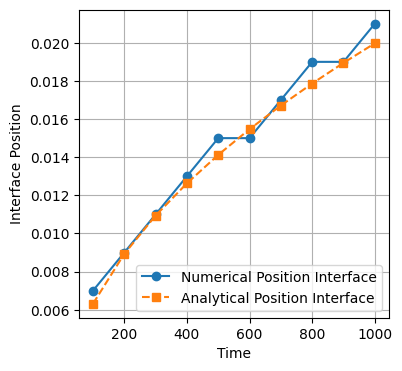

In [8]:
avg_num_pos_interface= return_approximate_interface_location(df_list, 273, 0.5)
num_pos_interface = []
for pos_data in avg_num_pos_interface:
    num_pos_interface.append(pos_data['x_coords'][numpy.min((pos_data['temp_idx'], pos_data['vol_frac_idx']))])
    
timesteps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
init_vars = stefan_variables(
    c_p = 4200,
    kappa = 0.6,
    rho = 1000,
    T_l = 300,
    T_m = 273,
    h_m = 100000,
    quadrature= mod_gaussQuad.legendreGaussQuad(ngp= 10, dim= 1)
)

analytical_pos_interface = analytical_stefan.interface_position(vars= init_vars, t_all = timesteps)

# Plot
plt.figure(figsize=(4,4))
plt.plot(timesteps, num_pos_interface, label="Numerical Position Interface", marker='o', linestyle='-')
plt.plot(timesteps, analytical_pos_interface, label="Analytical Position Interface", marker='s', linestyle='--')

# Labels and Title
plt.xlabel("Time")
plt.ylabel("Interface Position")
plt.legend()

# Show plot
plt.grid()
plt.show()

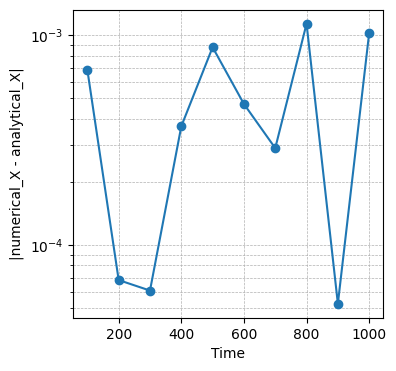

In [5]:
abs_pos_err = []
[abs_pos_err.append(abs(an_pos - num_pos)) for an_pos, num_pos in zip(analytical_pos_interface, num_pos_interface)]

# Plot
plt.figure(figsize=(4,4))
plt.plot(timesteps, abs_pos_err, label="Absolute Error", marker='o', linestyle='-')
#plt.plot(timesteps, analytical_pos_interface, label="Analytical Position Interface", marker='s', linestyle='--')

# Labels and Title
plt.xlabel("Time")
plt.yscale('log')
plt.ylabel("|numerical_X - analytical_X|")
#plt.legend(r'2e-3')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [6]:
temp_data = return_temperature_data(df_list)

In [ ]:
L2_data = []
L_inf_data = []
for t, data in zip(timesteps, temp_data):
    out_X = data['x_coords']
    el_vol = 0.002*0.002
    #temperature_profile(vars, x_all: bool = False, x_loc: float = 100, t: float = -1.0, t_all: List[float] = None):
    analytical_temp = analytical_stefan.temperature_profile(vars= init_vars, x_all= True, x_loc= out_X, t= t)
    #print(analytical_temp[0][0][0:5])
    #print(data['temperature'][0:5])
    #print('-----')
    abs_err = []
    for num_temp, an_temp in zip(data['temperature'],analytical_temp[0][0]):
        abs_err.append(abs(num_temp - an_temp))
    L2_err = 0
    for error in abs_err:
        L2_err += (error**2)*el_vol
    L2_data.append(numpy.sqrt(L2_err/len(abs_err)))
    L_inf_data.append(numpy.max(abs_err))

c:\Users\harsh\Documents\thesis\stefan_problem\mod_stefan.py:47: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  roots = fsolve(f_lam, lam_init)


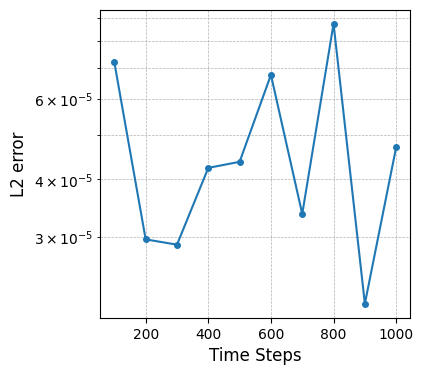

In [52]:

log_bool = True
plt.figure(figsize=(4,4))
plt.plot(timesteps, L2_data, marker='o', markersize = '4', label='L2 Data')
#if log_bool is True:
    #plt.xscale('log')

    # Customize the plot
    #plt.title("L2 Data Plot", fontsize=16)
plt.xlabel(r"Time Steps", fontsize=12)
plt.ylabel(r"L2 error", fontsize=12)
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    #plt.legend(fontsize=12)

    # Display the plot
plt.show()


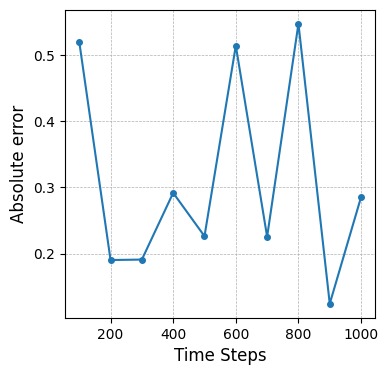

In [51]:
log_bool = True
plt.figure(figsize=(4, 4))
plt.plot(timesteps, L_inf_data, marker='o', markersize = '4', label='L2 Data')
#if log_bool is True:
    #plt.xscale('log')

    # Customize the plot
    #plt.title("L2 Data Plot", fontsize=16)
plt.xlabel(r"Time Steps", fontsize=12)
plt.ylabel(r"Absolute error", fontsize=12)
#plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    #plt.legend(fontsize=12)

    # Display the plot
plt.show()